# House Prices — Advanced Regression Techniques
### model_experiment.ipynb

ამ notebook-ში გავივლით ყველა ეტაპს:
1. Data Loading & EDA
2. Data Cleaning
3. Feature Engineering
4. Feature Selection
5. Training & Hyperparameter Tuning
6. MLflow Logging

---
## MLflow + DagsHub Setup

ყველა ექსპერიმენტი დაილოგება DagsHub-ზე MLflow-ის გამოყენებით.
ეს cell გაუშვი **პირველ ყოვლისა**, ერთხელ — შემდეგ გადახვალ EDA-ზე.

In [1]:
import os
import dagshub
import mlflow

# DagsHub credentials — token ჩასვი აქ
DAGSHUB_TOKEN = "f4ea983ab060d1f20cfb8498628e3b6c43805132"

os.environ["MLFLOW_TRACKING_USERNAME"] = "ashos22"
os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN

dagshub.init(repo_owner='ashos22', repo_name='House-Prices', mlflow=True)
mlflow.set_experiment('house-prices-regression')

print('MLflow tracking URI:', mlflow.get_tracking_uri())
print('Connected to DagsHub!')

c:\Users\99557\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Accessing as ashos22

Initialized MLflow to track repo "ashos22/House-Prices"

Repository ashos22/House-Prices initialized!

MLflow tracking URI: https://dagshub.com/ashos22/House-Prices.mlflow
Connected to DagsHub!


---
# 1. Data Loading & EDA



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')

print(f'Train ზომა: {train.shape}')  
print(f'Test ზომა:  {test.shape}')   
train.head()

Train ზომა: (1460, 81)
Test ზომა:  (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:

train.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

In [5]:

print('SalePrice სტატისტიკა:')
print(train['SalePrice'].describe())
print()
print(f'Skewness: {train["SalePrice"].skew():.4f}')


SalePrice სტატისტიკა:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Skewness: 1.8829


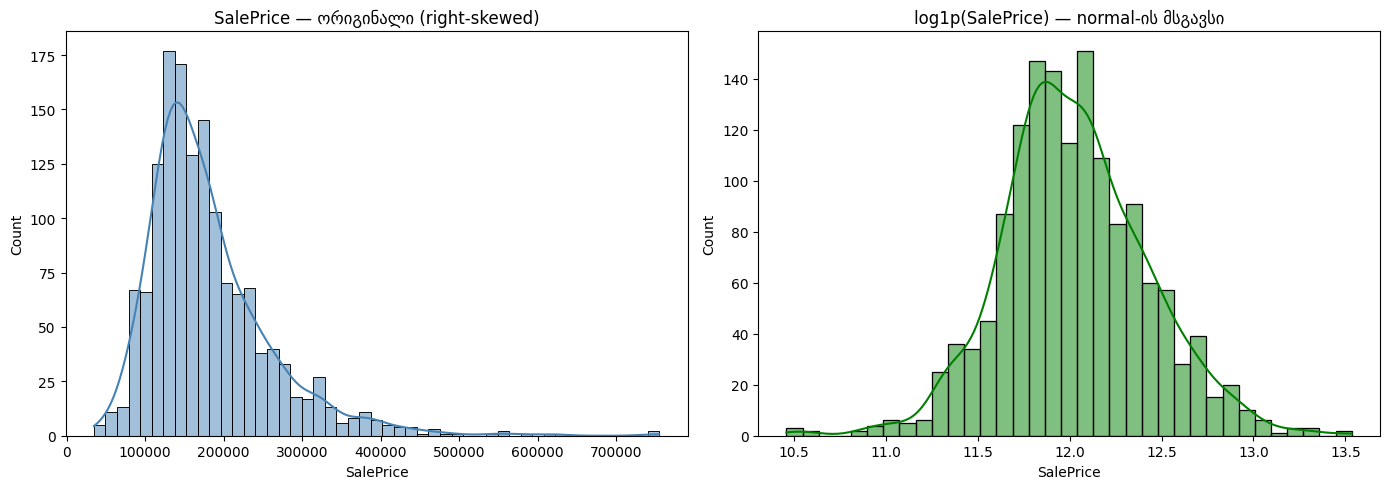

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('SalePrice — ორიგინალი (right-skewed)')

sns.histplot(np.log1p(train['SalePrice']), kde=True, ax=axes[1], color='green')
axes[1].set_title('log1p(SalePrice) — normal-ის მსგავსი')

plt.tight_layout()
plt.show()


In [7]:

missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)

missing_df = pd.DataFrame({'Count': missing, '%': missing_pct})
print(missing_df)
print(f'\nNaN-ების მქონე სვეტების რაოდენობა: {len(missing_df)}')

              Count      %
PoolQC         1453  99.52
MiscFeature    1406  96.30
Alley          1369  93.77
Fence          1179  80.75
MasVnrType      872  59.73
FireplaceQu     690  47.26
LotFrontage     259  17.74
GarageType       81   5.55
GarageYrBlt      81   5.55
GarageFinish     81   5.55
GarageQual       81   5.55
GarageCond       81   5.55
BsmtFinType2     38   2.60
BsmtExposure     38   2.60
BsmtFinType1     37   2.53
BsmtCond         37   2.53
BsmtQual         37   2.53
MasVnrArea        8   0.55
Electrical        1   0.07

NaN-ების მქონე სვეტების რაოდენობა: 19


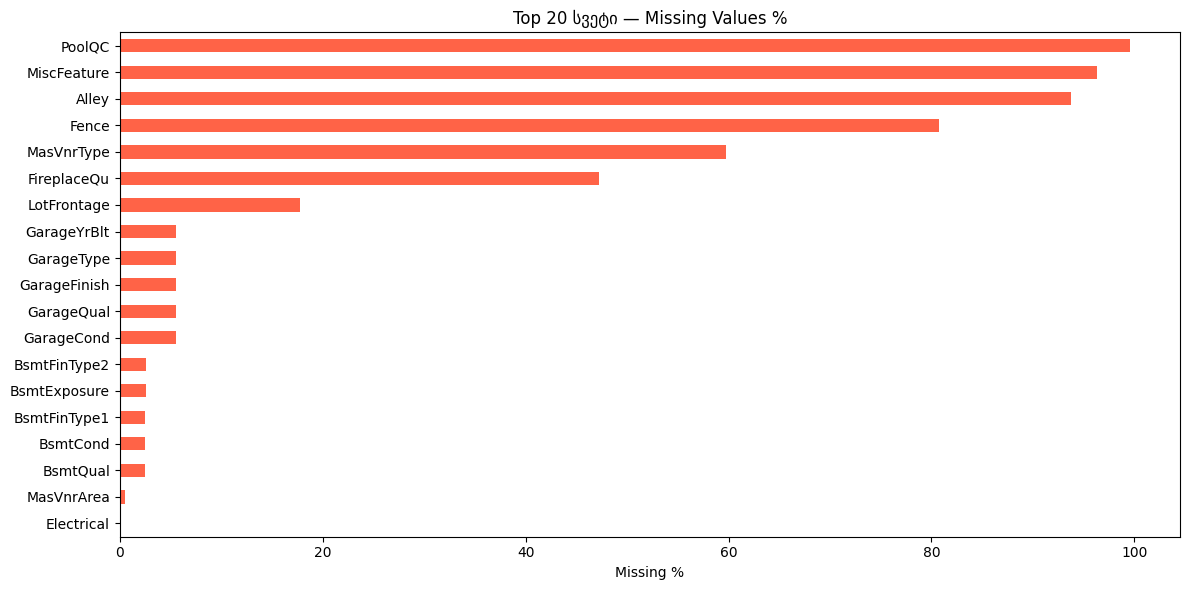

In [8]:

plt.figure(figsize=(12, 6))
missing_pct.head(20).sort_values().plot(kind='barh', color='tomato')
plt.title('Top 20 სვეტი — Missing Values %')
plt.xlabel('Missing %')
plt.tight_layout()
plt.show()

In [9]:

corr = train.corr(numeric_only=True)
top15 = corr['SalePrice'].abs().sort_values(ascending=False).head(16)
top15_cols = top15.index.tolist()

print('Top 15 ფიჩერი:')
print(top15[1:])

Top 15 ფიჩერი:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64


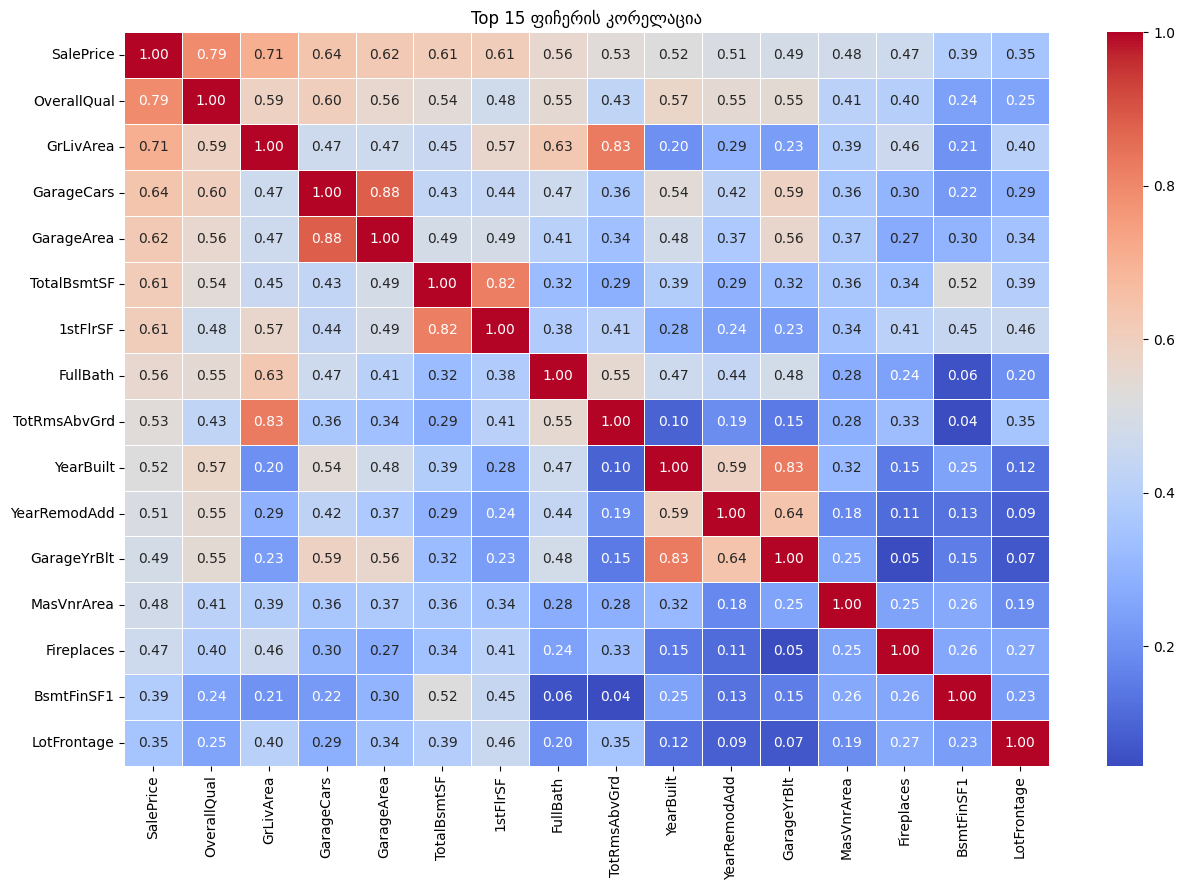

In [10]:

plt.figure(figsize=(13, 9))
sns.heatmap(train[top15_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Top 15 ფიჩერის კორელაცია')
plt.tight_layout()
plt.show()

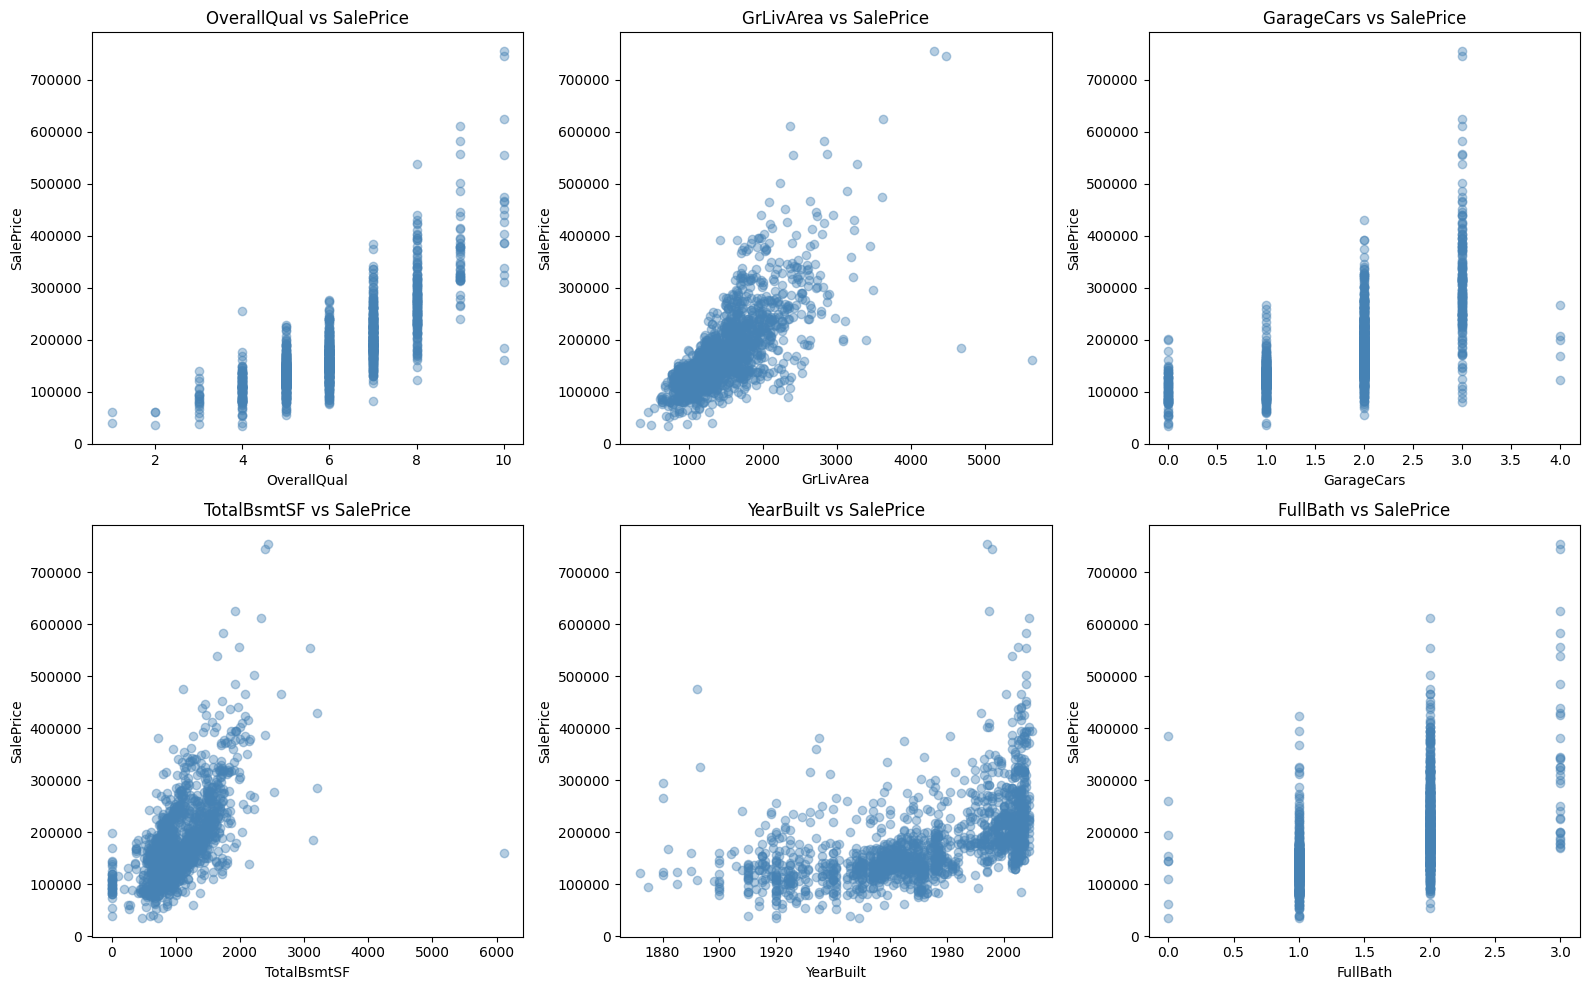

In [11]:

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt', 'FullBath']

for ax, feat in zip(axes.flat, features):
    ax.scatter(train[feat], train['SalePrice'], alpha=0.4, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('SalePrice')
    ax.set_title(f'{feat} vs SalePrice')

plt.tight_layout()
plt.show()

In [12]:
print(f'Train: {train.shape} | Test: {test.shape}')
print(f'SalePrice — min: ${train["SalePrice"].min():,.0f} | max: ${train["SalePrice"].max():,.0f}')
print(f'Missing value columns: {len(missing_df)} | Worst: {missing_pct.idxmax()} {missing_pct.max():.1f}%')

Train: (1460, 81) | Test: (1459, 80)
SalePrice — min: $34,900 | max: $755,000
Missing value columns: 19 | Worst: PoolQC 99.5%


---
# 2. Data Cleaning



In [13]:
# Outlier Removal
# 2 houses: GrLivArea > 4000 but SalePrice < 300k — clear outliers
train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))].reset_index(drop=True)

In [14]:
y = np.log1p(train['SalePrice'])

In [15]:
ntrain = train.shape[0]
ntest  = test.shape[0]

all_data = pd.concat(
    [train.drop(['SalePrice', 'Id'], axis=1),
     test.drop('Id', axis=1)],
    axis=0
).reset_index(drop=True)

In [ ]:


none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in none_cols:
    all_data[col] = all_data[col].fillna('None')

In [ ]:


zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)

In [ ]:


all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

In [ ]:


for col in all_data.select_dtypes(include='object').columns:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

for col in all_data.select_dtypes(include=[np.number]).columns:
    all_data[col] = all_data[col].fillna(all_data[col].median())

# დარჩა NaN?
remaining = all_data.isnull().sum().sum()
print(f'დარჩენილი NaN: {remaining}')  # უნდა იყოს 0

დარჩენილი NaN: 0


In [ ]:

all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)
all_data['MoSold']     = all_data['MoSold'].astype(str)
all_data['YrSold']     = all_data['YrSold'].astype(str)

---
# 3. Feature Engineering

არსებული სვეტებიდან ვქმნით ახალ, უფრო სასარგებლო სვეტებს.


- `TotalSF` — სახლის სულ ფართობი
- `TotalBath` — სულ აბაზანები
- `TotalPorchSF` — ვერანდების ჯამი
- `HouseAge` — სახლის ასაკი
- `IsRemodeled` — გარემონტებულია თუ არა
- `HasPool`, `HasGarage` და სხვა binary flags


In [ ]:

all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']


all_data['TotalPorchSF'] = (all_data['OpenPorchSF'] + all_data['3SsnPorch'] +
                             all_data['EnclosedPorch'] + all_data['ScreenPorch'] +
                             all_data['WoodDeckSF'])


all_data['TotalBath'] = (all_data['FullBath'] + 0.5 * all_data['HalfBath'] +
                          all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath'])

In [ ]:

all_data['HouseAge']   = 2010 - all_data['YearBuilt']


all_data['RemodelAge'] = 2010 - all_data['YearRemodAdd']


all_data['IsRemodeled'] = (all_data['YearBuilt'] != all_data['YearRemodAdd']).astype(int)

In [ ]:


all_data['HasPool']      = (all_data['PoolArea'] > 0).astype(int)
all_data['HasGarage']    = (all_data['GarageArea'] > 0).astype(int)
all_data['Has2ndFloor']  = (all_data['2ndFlrSF'] > 0).astype(int)
all_data['HasBsmt']      = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasFireplace'] = (all_data['Fireplaces'] > 0).astype(int)

In [ ]:


all_data['Qual_x_TotalSF']   = all_data['OverallQual'] * all_data['TotalSF']
all_data['Qual_x_GrLivArea'] = all_data['OverallQual'] * all_data['GrLivArea']
all_data['Qual_x_YearBuilt'] = all_data['OverallQual'] * all_data['YearBuilt']

In [ ]:


qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual', 'FireplaceQu',
                'GarageQual', 'GarageCond', 'PoolQC']

for col in ordinal_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].map(qual_map).fillna(0)

In [ ]:


before = all_data.shape[1]
all_data = pd.get_dummies(all_data)
after = all_data.shape[1]

print(f'One-Hot Encoding:')
print(f'  სვეტები before: {before}')
print(f'  სვეტები after:  {after}')
print(f'  დაემატა: {after - before} ახალი სვეტი')

One-Hot Encoding:
  სვეტები before: 93
  სვეტები after:  305
  დაემატა: 212 ახალი სვეტი


In [ ]:


from scipy.stats import skew
from scipy.special import boxcox1p

numeric_feats = all_data.dtypes[all_data.dtypes != 'object'].index
skewed_feats  = all_data[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewed_feats  = skewed_feats[abs(skewed_feats) > 0.75]  # მხოლოდ ძლიერ skewed-ები

print(f'Skewed ფიჩერები (|skew|>0.75): {len(skewed_feats)}')

for feat in skewed_feats.index:
    all_data[feat] = boxcox1p(all_data[feat], 0.15)

print(f'Box-Cox გარდაქმნა გამოყენდა {len(skewed_feats)} ფიჩერზე')

Skewed ფიჩერები (|skew|>0.75): 270
Box-Cox გარდაქმნა გამოყენდა 270 ფიჩერზე


In [ ]:


X      = all_data[:ntrain].copy()
X_test = all_data[ntrain:].copy()

---
# 4. Feature Selection


1. **Correlation Filter** — SalePrice-თან კორელაცია > 0.1
2. **Lasso Selection** — Lasso მოდელი ზედმეტ სვეტებს ნულზე მიჰყავს
3. **Random Forest Importance** — tree-ები გვეუბნებიან რომელი სვეტი მნიშვნელოვანია


In [29]:
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression

# Scaling — RobustScaler outlier-ების მიმართ გამძლეა
scaler   = RobustScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:


corr_with_target = X.corrwith(y).abs().sort_values(ascending=False)
corr_selected    = corr_with_target[corr_with_target > 0.1].index.tolist()

print(f'Correlation Filter (>0.1):')
print(f'  შერჩეული სვეტები: {len(corr_selected)}')
print()
print('Top 10 სვეტი კორელაციით:')
print(corr_with_target.head(10))

Correlation Filter (>0.1):
  შერჩეული სვეტები: 145

Top 10 სვეტი კორელაციით:
Qual_x_TotalSF      0.893885
Qual_x_GrLivArea    0.856167
Qual_x_YearBuilt    0.827942
TotalSF             0.822759
OverallQual         0.821405
GrLivArea           0.738000
ExterQual           0.681381
GarageCars          0.681033
TotalBath           0.676678
KitchenQual         0.669990
dtype: float64


In [ ]:


lasso_sel = Lasso(alpha=0.0005, max_iter=5000, random_state=42)
lasso_sel.fit(X_scaled, y)

lasso_coefs    = pd.Series(np.abs(lasso_sel.coef_), index=X.columns)
lasso_selected = lasso_coefs[lasso_coefs > 0].index.tolist()

print(f'Lasso Selection (alpha=0.0005):')
print(f'  შერჩეული სვეტები (non-zero): {len(lasso_selected)}')
print(f'  ამოღებული სვეტები (zero):    {X.shape[1] - len(lasso_selected)}')

Lasso Selection (alpha=0.0005):
  შერჩეული სვეტები (non-zero): 96
  ამოღებული სვეტები (zero):    209


In [ ]:


rf_sel = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_sel.fit(X, y)

rf_importance = pd.Series(rf_sel.feature_importances_, index=X.columns).sort_values(ascending=False)
rf_selected   = rf_importance[rf_importance > 0.0005].index.tolist()

print(f'Random Forest Importance (>0.0005):')
print(f'  შერჩეული სვეტები: {len(rf_selected)}')
print()
print('Top 10 სვეტი RF importance-ით:')
print(rf_importance.head(10))

Random Forest Importance (>0.0005):
  შერჩეული სვეტები: 57

Top 10 სვეტი RF importance-ით:
Qual_x_TotalSF      0.780418
Qual_x_GrLivArea    0.027816
BsmtFinSF1          0.009159
LotArea             0.008537
BsmtUnfSF           0.008148
GarageArea          0.007349
GarageCars          0.007209
OverallCond         0.006502
Qual_x_YearBuilt    0.006078
TotalSF             0.005751
dtype: float64


=== Feature Selection შედარება ===
სულ სვეტები:              305
Correlation Filter:       145
Lasso Selection:          96
Random Forest Importance: 57


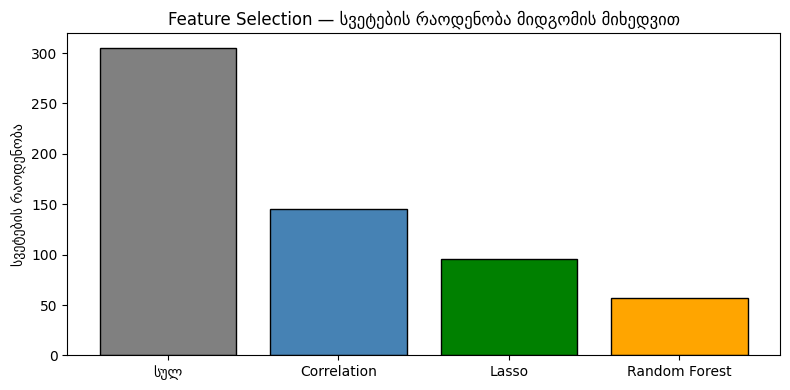

In [ ]:

print('=== Feature Selection შედარება ===')
print(f'სულ სვეტები:              {X.shape[1]}')
print(f'Correlation Filter:       {len(corr_selected)}')
print(f'Lasso Selection:          {len(lasso_selected)}')
print(f'Random Forest Importance: {len(rf_selected)}')


plt.figure(figsize=(8, 4))
methods = ['სულ', 'Correlation', 'Lasso', 'Random Forest']
counts  = [X.shape[1], len(corr_selected), len(lasso_selected), len(rf_selected)]
colors  = ['gray', 'steelblue', 'green', 'orange']
plt.bar(methods, counts, color=colors, edgecolor='black')
plt.title('Feature Selection — სვეტების რაოდენობა მიდგომის მიხედვით')
plt.ylabel('სვეტების რაოდენობა')
plt.tight_layout()
plt.show()

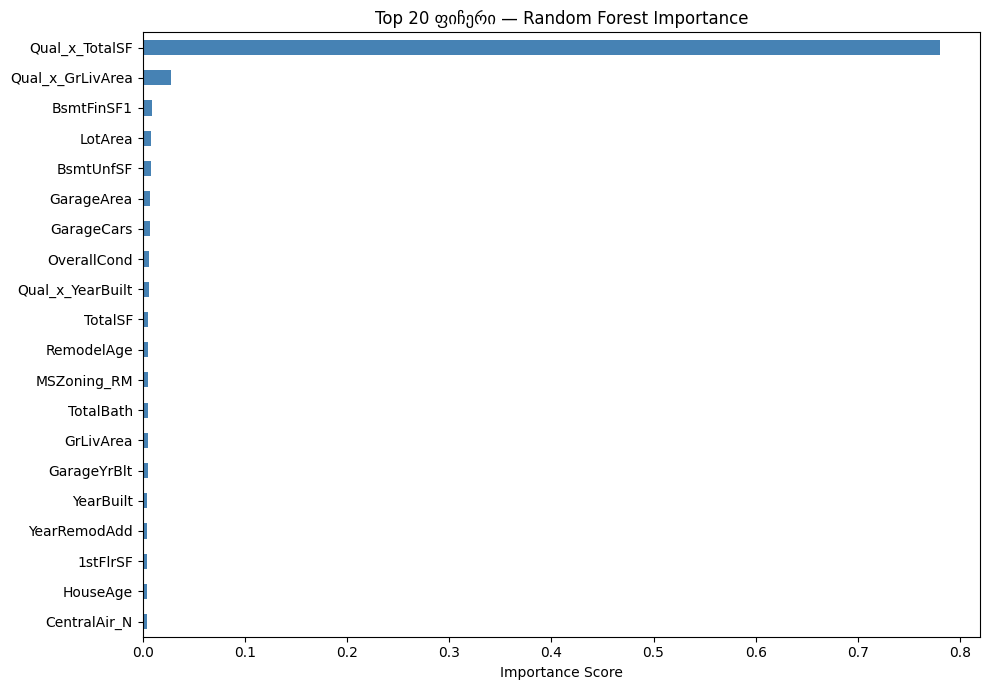

In [ ]:

plt.figure(figsize=(10, 7))
rf_importance.head(20).sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 ფიჩერი — Random Forest Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:

from collections import Counter

all_selected = corr_selected + lasso_selected + rf_selected
vote_counts  = Counter(all_selected)


final_features = [feat for feat, count in vote_counts.items() if count >= 2]
final_features = [f for f in final_features if f in X.columns]

print(f'საბოლოო სვეტების რაოდენობა (≥2 მიდგომა): {len(final_features)}')
print()

X_final    = X[final_features]
X_test_final = X_test[final_features]


scaler_final   = RobustScaler()
X_final_sc     = scaler_final.fit_transform(X_final)
X_test_final_sc = scaler_final.transform(X_test_final)

print(f'X_final: {X_final.shape} | X_test_final: {X_test_final.shape}')

საბოლოო სვეტების რაოდენობა (≥2 მიდგომა): 86

X_final: (1458, 86) | X_test_final: (1459, 86)


---
# 5. Model Training + MLflow Logging

ვიწყებთ ყველაზე მარტივი მოდელით: **Linear Regression (Baseline)**

ველოდებით:
- Train RMSE პატარა (training data-ს კარგად ისწავლა)
- CV RMSE გაცილებით დიდი (ახალ მონაცემებზე ვერ მუშაობს)
- ეს = **Overfitting** — 300+ სვეტი, regularization-ის გარეშე

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
import mlflow, mlflow.sklearn
import sys, io

kf = KFold(n_splits=5, shuffle=True, random_state=42)
all_results = {}

def evaluate_and_log(run_name, model, X_tr, y_tr, params, tags):
    _saved_stdout = sys.stdout
    try:
        sys.stdout = io.StringIO()
        with mlflow.start_run(run_name=run_name):
            mlflow.set_tags(tags)
            mlflow.log_params(params)
            cv_scores = np.sqrt(-cross_val_score(
                model, X_tr, y_tr,
                scoring='neg_mean_squared_error', cv=kf
            ))
            cv_mean = cv_scores.mean()
            cv_std  = cv_scores.std()
            model.fit(X_tr, y_tr)
            train_preds = model.predict(X_tr)
            train_rmse  = np.sqrt(mean_squared_error(y_tr, train_preds))
            train_r2    = r2_score(y_tr, train_preds)
            gap = abs(cv_mean - train_rmse)
            mlflow.log_metric('cv_rmse',     round(cv_mean,    5))
            mlflow.log_metric('cv_std',      round(cv_std,     5))
            mlflow.log_metric('train_rmse',  round(train_rmse, 5))
            mlflow.log_metric('train_r2',    round(train_r2,   5))
            mlflow.log_metric('overfit_gap', round(gap,        5))
    finally:
        sys.stdout = _saved_stdout
    print(f'[{run_name}]')
    print(f'  CV RMSE:     {cv_mean:.5f} +/- {cv_std:.5f}')
    print(f'  Train RMSE:  {train_rmse:.5f}')
    print(f'  Train R2:    {train_r2:.5f}')
    if gap > 0.03:
        print(f'  WARNING: Overfit gap = {gap:.5f}')
    return model, cv_mean

## Model 1: Linear Regression (Baseline)

ყველაზე მარტივი linear model. Hyperparameter-ები არ აქვს.
ველოდებით Good fit-ს (Feature Selection-მა უკვე გაასუფთავა სვეტები).

In [37]:
lr_model, lr_score = evaluate_and_log(
    run_name = 'LinearRegression_baseline',
    model    = LinearRegression(),
    X_tr     = X_final_sc,
    y_tr     = y,
    params   = {'model': 'LinearRegression', 'regularization': 'None'},
    tags     = {'model_type': 'linear', 'stage': 'baseline'}
)
all_results['LinearRegression'] = lr_score

[LinearRegression_baseline]
  CV RMSE:     0.10943 +/- 0.00586
  Train RMSE:  0.10045
  Train R2:    0.93680


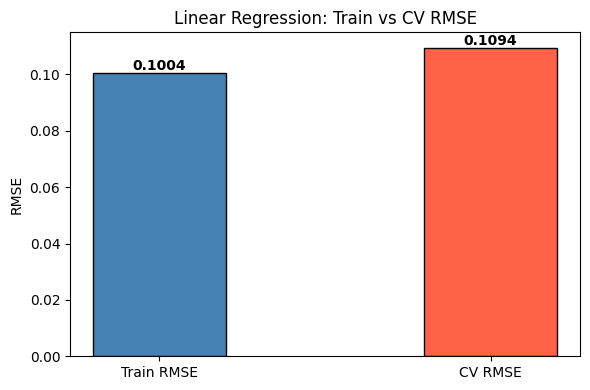

Train RMSE : 0.10045
CV RMSE    : 0.10943
Overfit gap: 0.00898


In [38]:
lr_check = LinearRegression()
cv_s = np.sqrt(-cross_val_score(
    lr_check, X_final_sc, y,
    scoring='neg_mean_squared_error', cv=kf
))
lr_check.fit(X_final_sc, y)
tr_rmse = np.sqrt(mean_squared_error(y, lr_check.predict(X_final_sc)))
cv_rmse = cv_s.mean()
gap = abs(cv_rmse - tr_rmse)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ['Train RMSE', 'CV RMSE'],
    [tr_rmse, cv_rmse],
    color=['steelblue', 'tomato'],
    edgecolor='black', width=0.4
)
for bar, val in zip(bars, [tr_rmse, cv_rmse]):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.001, f'{val:.4f}',
            ha='center', fontweight='bold')
ax.set_title('Linear Regression: Train vs CV RMSE')
ax.set_ylabel('RMSE')
plt.tight_layout()
plt.show()

print(f'Train RMSE : {tr_rmse:.5f}')
print(f'CV RMSE    : {cv_rmse:.5f}')
print(f'Overfit gap: {gap:.5f}')

---
## Model 2: Ridge Regression (L2 Regularization)

Ridge-ს აქვს ერთი hyperparameter — `alpha`:
- **მცირე alpha** (0.001) → regularization სუსტია → overfitting
- **საშუალო alpha** (10–50) → კარგი ბალანსი
- **დიდი alpha** (1000+) → regularization ძლიერია → underfitting

In [39]:
from sklearn.linear_model import Ridge

# alpha=0.001 
ridge_001, score_001 = evaluate_and_log(
    run_name = 'Ridge_alpha0.001',
    model    = Ridge(alpha=0.001),
    X_tr     = X_final_sc,
    y_tr     = y,
    params   = {'model': 'Ridge', 'alpha': 0.001},
    tags     = {'model_type': 'linear', 'stage': 'ridge'}
)
all_results['Ridge_0.001'] = score_001

[Ridge_alpha0.001]
  CV RMSE:     0.10941 +/- 0.00584
  Train RMSE:  0.10045
  Train R2:    0.93680


In [40]:
# alpha=10 
ridge_10, score_10 = evaluate_and_log(
    run_name = 'Ridge_alpha10',
    model    = Ridge(alpha=10),
    X_tr     = X_final_sc,
    y_tr     = y,
    params   = {'model': 'Ridge', 'alpha': 10},
    tags     = {'model_type': 'linear', 'stage': 'ridge'}
)
all_results['Ridge_10'] = score_10

[Ridge_alpha10]
  CV RMSE:     0.11122 +/- 0.00783
  Train RMSE:  0.10394
  Train R2:    0.93233


In [41]:
# alpha=50 
ridge_50, score_50 = evaluate_and_log(
    run_name = 'Ridge_alpha50',
    model    = Ridge(alpha=50),
    X_tr     = X_final_sc,
    y_tr     = y,
    params   = {'model': 'Ridge', 'alpha': 50},
    tags     = {'model_type': 'linear', 'stage': 'ridge'}
)
all_results['Ridge_50'] = score_50

[Ridge_alpha50]
  CV RMSE:     0.11533 +/- 0.00851
  Train RMSE:  0.10965
  Train R2:    0.92469


In [42]:
# alpha=500 
ridge_500, score_500 = evaluate_and_log(
    run_name = 'Ridge_alpha500',
    model    = Ridge(alpha=500),
    X_tr     = X_final_sc,
    y_tr     = y,
    params   = {'model': 'Ridge', 'alpha': 500},
    tags     = {'model_type': 'linear', 'stage': 'ridge'}
)
all_results['Ridge_500'] = score_500

[Ridge_alpha500]
  CV RMSE:     0.12777 +/- 0.00764
  Train RMSE:  0.12342
  Train R2:    0.90460


In [43]:
# alpha=5000 — 
ridge_5000, score_5000 = evaluate_and_log(
    run_name = 'Ridge_alpha5000',
    model    = Ridge(alpha=5000),
    X_tr     = X_final_sc,
    y_tr     = y,
    params   = {'model': 'Ridge', 'alpha': 5000},
    tags     = {'model_type': 'linear', 'stage': 'ridge'}
)
all_results['Ridge_5000'] = score_5000

[Ridge_alpha5000]
  CV RMSE:     0.19154 +/- 0.01027
  Train RMSE:  0.17887
  Train R2:    0.79961


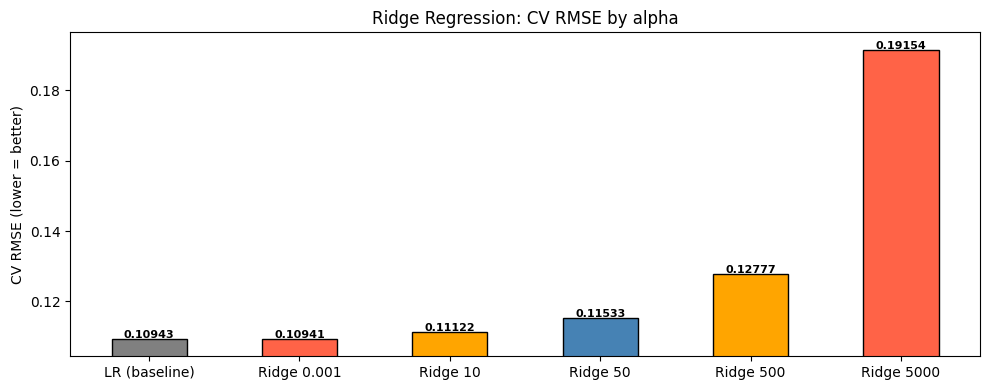

Best: Ridge 0.001  |  CV RMSE = 0.10941


In [44]:
ridge_scores = {
    'LR (baseline)': all_results['LinearRegression'],
    'Ridge 0.001':   score_001,
    'Ridge 10':      score_10,
    'Ridge 50':      score_50,
    'Ridge 500':     score_500,
    'Ridge 5000':    score_5000,
}

labels   = list(ridge_scores.keys())
cv_rmses = list(ridge_scores.values())
colors   = ['gray', 'tomato', 'orange', 'steelblue', 'orange', 'tomato']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, cv_rmses, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, cv_rmses):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0003,
            f'{val:.5f}', ha='center', fontsize=8, fontweight='bold')
ax.set_title('Ridge Regression: CV RMSE by alpha')
ax.set_ylabel('CV RMSE (lower = better)')
ax.set_ylim(min(cv_rmses) - 0.005, max(cv_rmses) + 0.005)
plt.tight_layout()
plt.show()

best_name = labels[cv_rmses.index(min(cv_rmses))]
print(f'Best: {best_name}  |  CV RMSE = {min(cv_rmses):.5f}')

---
## Model 3: Lasso Regression (L1 Regularization)


`alpha` parameter:
- **მცირე alpha** (0.0001) → regularization სუსტი → overfitting
- **საშუალო alpha** (0.001) → expected sweet spot
- **დიდი alpha** (0.1+) → ბევრი სვეტი ნულდება → underfitting

In [45]:
from sklearn.linear_model import Lasso

lasso_0001, score_l0001 = evaluate_and_log(
    run_name = 'Lasso_alpha0.0001',
    model    = Lasso(alpha=0.0001, max_iter=5000),
    X_tr     = X_final_sc,
    y_tr     = y,
    params   = {'model': 'Lasso', 'alpha': 0.0001},
    tags     = {'model_type': 'linear', 'stage': 'lasso'}
)
all_results['Lasso_0.0001'] = score_l0001

[Lasso_alpha0.0001]
  CV RMSE:     0.10930 +/- 0.00607
  Train RMSE:  0.10088
  Train R2:    0.93625


In [46]:
lasso_001, score_l001 = evaluate_and_log(
    run_name = 'Lasso_alpha0.001',
    model    = Lasso(alpha=0.001, max_iter=5000),
    X_tr     = X_final_sc,
    y_tr     = y,
    params   = {'model': 'Lasso', 'alpha': 0.001},
    tags     = {'model_type': 'linear', 'stage': 'lasso'}
)
all_results['Lasso_0.001'] = score_l001

[Lasso_alpha0.001]
  CV RMSE:     0.11523 +/- 0.00819
  Train RMSE:  0.10845
  Train R2:    0.92633


In [47]:
lasso_01, score_l01 = evaluate_and_log(
    run_name = 'Lasso_alpha0.01',
    model    = Lasso(alpha=0.01, max_iter=5000),
    X_tr     = X_final_sc,
    y_tr     = y,
    params   = {'model': 'Lasso', 'alpha': 0.01},
    tags     = {'model_type': 'linear', 'stage': 'lasso'}
)
all_results['Lasso_0.01'] = score_l01

[Lasso_alpha0.01]
  CV RMSE:     0.13430 +/- 0.00757
  Train RMSE:  0.13136
  Train R2:    0.89193


In [48]:
lasso_1, score_l1 = evaluate_and_log(
    run_name = 'Lasso_alpha0.1',
    model    = Lasso(alpha=0.1, max_iter=5000),
    X_tr     = X_final_sc,
    y_tr     = y,
    params   = {'model': 'Lasso', 'alpha': 0.1},
    tags     = {'model_type': 'linear', 'stage': 'lasso'}
)
all_results['Lasso_0.1'] = score_l1

[Lasso_alpha0.1]
  CV RMSE:     0.21719 +/- 0.00881
  Train RMSE:  0.21675
  Train R2:    0.70576


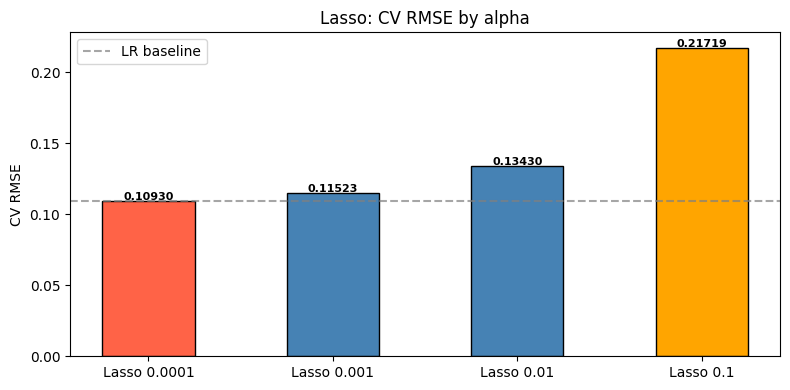

Best Lasso: Lasso 0.0001  |  CV RMSE = 0.10930
LR baseline:        0.10943


In [49]:
lasso_scores = {
    'Lasso 0.0001': score_l0001,
    'Lasso 0.001':  score_l001,
    'Lasso 0.01':   score_l01,
    'Lasso 0.1':    score_l1,
}

labels   = list(lasso_scores.keys())
cv_rmses = list(lasso_scores.values())

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, cv_rmses, color=['tomato', 'steelblue', 'steelblue', 'orange'],
              edgecolor='black', width=0.5)
for bar, val in zip(bars, cv_rmses):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0005,
            f'{val:.5f}', ha='center', fontsize=8, fontweight='bold')
ax.axhline(y=all_results['LinearRegression'], color='gray', linestyle='--', alpha=0.7, label='LR baseline')
ax.set_title('Lasso: CV RMSE by alpha')
ax.set_ylabel('CV RMSE')
ax.legend()
plt.tight_layout()
plt.show()

best = min(lasso_scores, key=lasso_scores.get)
print(f'Best Lasso: {best}  |  CV RMSE = {lasso_scores[best]:.5f}')
print(f'LR baseline:        {all_results["LinearRegression"]:.5f}')

---
## Model 4: Decision Tree Regressor


ძირითადი hyperparameter: `max_depth`
- **max_depth=2:** 
- **max_depth=5:** 
- **max_depth=10:** 
- **max_depth=None:** 

In [50]:
from sklearn.tree import DecisionTreeRegressor

dt_2, score_dt2 = evaluate_and_log(
    run_name = 'DecisionTree_depth2',
    model    = DecisionTreeRegressor(max_depth=2, random_state=42),
    X_tr     = X_final_sc,
    y_tr     = y,
    params   = {'model': 'DecisionTree', 'max_depth': 2},
    tags     = {'model_type': 'tree', 'stage': 'decision_tree'}
)
all_results['DecisionTree_depth2'] = score_dt2

[DecisionTree_depth2]
  CV RMSE:     0.21975 +/- 0.00651
  Train RMSE:  0.21414
  Train R2:    0.71280


In [51]:
dt_5, score_dt5 = evaluate_and_log(
    run_name = 'DecisionTree_depth5',
    model    = DecisionTreeRegressor(max_depth=5, random_state=42),
    X_tr     = X_final_sc,
    y_tr     = y,
    params   = {'model': 'DecisionTree', 'max_depth': 5},
    tags     = {'model_type': 'tree', 'stage': 'decision_tree'}
)
all_results['DecisionTree_depth5'] = score_dt5

[DecisionTree_depth5]
  CV RMSE:     0.17732 +/- 0.00502
  Train RMSE:  0.13924
  Train R2:    0.87857


In [52]:
dt_10, score_dt10 = evaluate_and_log(
    run_name = 'DecisionTree_depth10',
    model    = DecisionTreeRegressor(max_depth=10, random_state=42),
    X_tr     = X_final_sc,
    y_tr     = y,
    params   = {'model': 'DecisionTree', 'max_depth': 10},
    tags     = {'model_type': 'tree', 'stage': 'decision_tree'}
)
all_results['DecisionTree_depth10'] = score_dt10

[DecisionTree_depth10]
  CV RMSE:     0.19004 +/- 0.00708
  Train RMSE:  0.05868
  Train R2:    0.97843


In [53]:
dt_none, score_dt_none = evaluate_and_log(
    run_name = 'DecisionTree_depthNone',
    model    = DecisionTreeRegressor(max_depth=None, random_state=42),
    X_tr     = X_final_sc,
    y_tr     = y,
    params   = {'model': 'DecisionTree', 'max_depth': -1},
    tags     = {'model_type': 'tree', 'stage': 'decision_tree'}
)
all_results['DecisionTree_depthNone'] = score_dt_none

[DecisionTree_depthNone]
  CV RMSE:     0.19159 +/- 0.00807
  Train RMSE:  0.00104
  Train R2:    0.99999


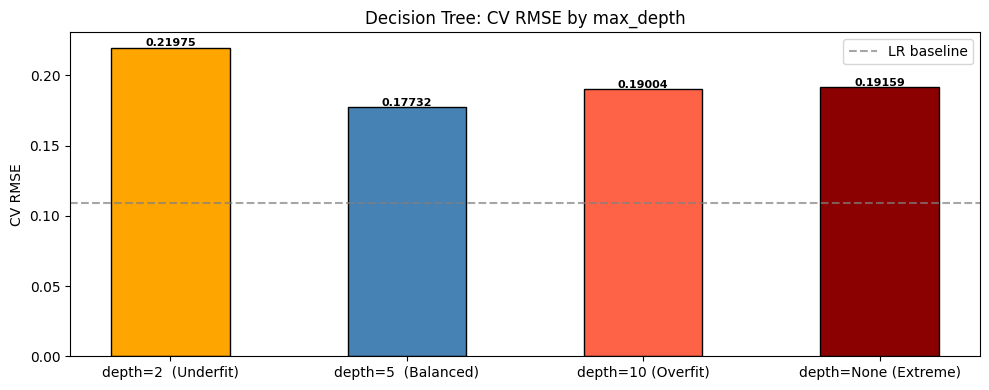

Best Decision Tree: depth=5  (Balanced)  |  CV RMSE = 0.17732
LR baseline:        0.10943


In [54]:
dt_scores = {
    'depth=2  (Underfit)':  score_dt2,
    'depth=5  (Balanced)':  score_dt5,
    'depth=10 (Overfit)':   score_dt10,
    'depth=None (Extreme)': score_dt_none,
}

labels   = list(dt_scores.keys())
cv_rmses = list(dt_scores.values())
colors   = ['orange', 'steelblue', 'tomato', 'darkred']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, cv_rmses, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, cv_rmses):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
            f'{val:.5f}', ha='center', fontsize=8, fontweight='bold')
ax.axhline(y=all_results['LinearRegression'], color='gray', linestyle='--', alpha=0.7, label='LR baseline')
ax.set_title('Decision Tree: CV RMSE by max_depth')
ax.set_ylabel('CV RMSE')
ax.legend()
plt.tight_layout()
plt.show()

best_dt = min(dt_scores, key=dt_scores.get)
print(f'Best Decision Tree: {best_dt}  |  CV RMSE = {dt_scores[best_dt]:.5f}')
print(f'LR baseline:        {all_results["LinearRegression"]:.5f}')

---
## Best Model — MLflow Model Registry

In [55]:
import mlflow.sklearn
import pickle, os

best_name = min(all_results, key=all_results.get)
print(f'Best overall model: {best_name}  |  CV RMSE = {all_results[best_name]:.5f}')

all_models = {
    'LinearRegression':       lr_model,
    'Ridge_0.001':            ridge_001,
    'Ridge_10':               ridge_10,
    'Ridge_50':               ridge_50,
    'Ridge_500':              ridge_500,
    'Ridge_5000':             ridge_5000,
    'Lasso_0.0001':           lasso_0001,
    'Lasso_0.001':            lasso_001,
    'Lasso_0.01':             lasso_01,
    'Lasso_0.1':              lasso_1,
    'DecisionTree_depth2':    dt_2,
    'DecisionTree_depth5':    dt_5,
    'DecisionTree_depth10':   dt_10,
    'DecisionTree_depthNone': dt_none,
}

best_model_obj = all_models[best_name]
best_model_obj.fit(X_final_sc, y)

_saved = sys.stdout
try:
    sys.stdout = io.StringIO()
    with mlflow.start_run(run_name='BEST_MODEL_REGISTERED') as run:
        mlflow.log_param('model_name', best_name)
        mlflow.log_metric('cv_rmse', all_results[best_name])
        mlflow.sklearn.log_model(
            best_model_obj,
            artifact_path='model',
            registered_model_name='HousePricesModel'
        )
        best_run_id = run.info.run_id
finally:
    sys.stdout = _saved

print(f'Registered: HousePricesModel')
print(f'Run ID: {best_run_id}')

os.makedirs('data', exist_ok=True)
with open('data/X_test_final_sc.pkl', 'wb') as f:
    pickle.dump(X_test_final_sc, f)
with open('data/test_ids.pkl', 'wb') as f:
    pickle.dump(test['Id'].values, f)
print('Test data saved.')

Best overall model: Lasso_0.0001  |  CV RMSE = 0.10930


2026/04/15 13:51:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 13:51:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'HousePricesModel' already exists. Creating a new version of this model...
2026/04/15 13:51:35 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePricesModel, version 2
Created version '2' of model 'HousePricesModel'.


Registered: HousePricesModel
Run ID: a21bb4579ac441e3aff38718da0f0b97
Test data saved.
